<div style="background-color: #d1ecf1; color: #0c5460; padding: 10px; border-radius: 5px; font-weight: bold; font-size: 18px;"><b><h3><align = "center">
  TASK 05 : Machine Learning Model Development
</div></h3></b>


---





**Module:** CCS3440 – Artificial Intelligence  
**Prediction Task:** Appointment No-Show Prediction (Option A)

This notebook loads the cleaned dataset produced by Task 03 and develops multiple machine learning models.


## 1. Import Libraries

In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not installed. The remaining required models will still be trained.")


## 2. Load the Clean Dataset from Task 03

In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
DATA_DIR = "/content/drive/MyDrive/AI_Coursework/Dataset"
file_path = os.path.join(DATA_DIR, "clean_dataset.csv")

df = pd.read_csv(file_path)

print("Clean dataset shape:", df.shape)
display(df.head())


Clean dataset shape: (1000, 19)


,age,gender,blood_group,department,diagnosis,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,consultation_fee_lkr,Age_Group,High_BP,Missed_Rate,no_show
0,53,1,1,1,8,10,1,0.0,1.0,127,75,117.0,211,26.1,2000,2,0,0.000,0
1,26,1,5,1,3,2,3,1.0,0.0,130,73,136.0,173,32.8,2000,4,0,0.250,0
2,22,1,4,4,1,22,7,1.0,1.0,141,64,90.0,176,29.4,2500,4,1,0.125,1
3,44,0,3,0,0,16,1,0.0,0.0,124,82,126.0,189,24.9,2000,0,0,0.000,0
4,51,0,6,3,6,12,4,0.0,1.0,119,81,65.0,195,27.0,4000,2,0,0.000,0


## 3. Define Features and Target

In [4]:
X = df.drop(columns=["no_show"])
y = df["no_show"].astype(int)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())


Feature matrix shape: (1000, 18)
Target shape: (1000,)

Features:
['age', 'gender', 'blood_group', 'department', 'diagnosis', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'consultation_fee_lkr', 'Age_Group', 'High_BP', 'Missed_Rate']


## 4. Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
display(y_train.value_counts(normalize=True).rename("Proportion").to_frame())

print("\nTest class distribution:")
display(y_test.value_counts(normalize=True).rename("Proportion").to_frame())


Train shape: (800, 18)
Test shape: (200, 18)

Train class distribution:


,Proportion
no_show,
0,0.505
1,0.495



Test class distribution:


,Proportion
no_show,
0,0.505
1,0.495


## 5. Model Development with Hyperparameter Tuning

At least three machine learning models are required by the coursework. Five models are developed:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)
5. XGBoost (when available)

`StandardScaler` is included inside each pipeline. This is important because Logistic Regression and KNN are scale-sensitive, while tree-based models are less sensitive. Using a pipeline also prevents scaling leakage during cross-validation.


In [6]:
models = {}
best_params = {}

# ------------------------------------------------------------
# 1. Logistic Regression
# ------------------------------------------------------------
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

lr_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

lr_search = GridSearchCV(
    lr_pipeline,
    lr_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

lr_search.fit(X_train, y_train)

models["Logistic Regression"] = lr_search.best_estimator_
best_params["Logistic Regression"] = lr_search.best_params_


# ------------------------------------------------------------
# 2. Decision Tree
# ------------------------------------------------------------
dt_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__criterion": ["gini", "entropy"]
}

dt_search = GridSearchCV(
    dt_pipeline,
    dt_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_search.fit(X_train, y_train)

models["Decision Tree"] = dt_search.best_estimator_
best_params["Decision Tree"] = dt_search.best_params_


# ------------------------------------------------------------
# 3. Random Forest
# ------------------------------------------------------------
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42))
])

rf_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

rf_search = GridSearchCV(
    rf_pipeline,
    rf_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

models["Random Forest"] = rf_search.best_estimator_
best_params["Random Forest"] = rf_search.best_params_


# ------------------------------------------------------------
# 4. K-Nearest Neighbors
# ------------------------------------------------------------
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"]
}

knn_search = GridSearchCV(
    knn_pipeline,
    knn_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

knn_search.fit(X_train, y_train)

models["KNN"] = knn_search.best_estimator_
best_params["KNN"] = knn_search.best_params_


# ------------------------------------------------------------
# 5. XGBoost
# ------------------------------------------------------------
if XGBOOST_AVAILABLE:
    xgb_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBClassifier(
            eval_metric="logloss",
            random_state=42
        ))
    ])

    xgb_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 4, 5],
        "model__learning_rate": [0.05, 0.1],
        "model__subsample": [0.8, 1.0]
    }

    xgb_search = GridSearchCV(
        xgb_pipeline,
        xgb_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    xgb_search.fit(X_train, y_train)

    models["XGBoost"] = xgb_search.best_estimator_
    best_params["XGBoost"] = xgb_search.best_params_


print("Models trained:")
for name in models:
    print("-", name)

print("\nBest hyperparameters:")
for name, params in best_params.items():
    print(f"\n{name}:")
    print(params)


Models trained:
- Logistic Regression
- Decision Tree
- Random Forest
- KNN
- XGBoost

Best hyperparameters:

Logistic Regression:
{'model__C': 0.1, 'model__solver': 'lbfgs'}

Decision Tree:
{'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_split': 10}

Random Forest:
{'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 200}

KNN:
{'model__n_neighbors': 7, 'model__weights': 'uniform'}

XGBoost:
{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}


## Cross-Validation Result Table

In [7]:
cv_summary = []
search_objects = {
    "Logistic Regression": lr_search,
    "Decision Tree": dt_search,
    "Random Forest": rf_search,
    "KNN": knn_search,
}
if XGBOOST_AVAILABLE:
    search_objects["XGBoost"] = xgb_search

for name, search in search_objects.items():
    cv_summary.append(
        {
            "Model": name,
            "CV Mean Accuracy": round(search.best_score_, 4),
            "CV Std Dev": round(
                search.cv_results_["std_test_score"][search.best_index_], 4
            ),
        }
    )

cv_df = pd.DataFrame(cv_summary).sort_values(
    by="CV Mean Accuracy", ascending=False
)
display(cv_df)

,Model,CV Mean Accuracy,CV Std Dev
0,Logistic Regression,0.6062,0.0529
2,Random Forest,0.6025,0.0337
4,XGBoost,0.5738,0.0378
1,Decision Tree,0.5638,0.0203
3,KNN,0.5262,0.0235


## 6. Quick Test Accuracy Comparison

In [8]:
results = []

for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    results.append({
        "Model": name,
        "Test Accuracy": round(acc, 4)
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Test Accuracy", ascending=False)
    .reset_index(drop=True)
)

display(results_df)


,Model,Test Accuracy
0,Logistic Regression,0.630
1,Random Forest,0.625
2,XGBoost,0.600
3,Decision Tree,0.545
4,KNN,0.540


## Accuracy Comparison Bar-chart

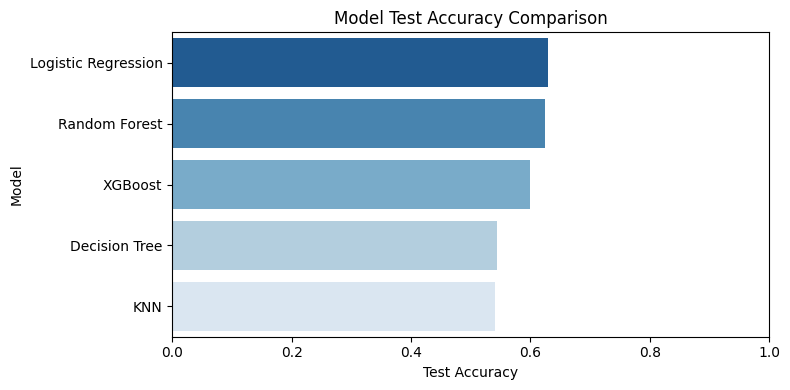

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.barplot(x="Test Accuracy", y="Model", data=results_df, palette="Blues_r")
plt.title("Model Test Accuracy Comparison")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Overfitting Check

In [10]:
overfit_check = []
for name, model in models.items():
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    overfit_check.append(
        {
            "Model": name,
            "Train Accuracy": round(train_acc, 4),
            "Test Accuracy": round(test_acc, 4),
            "Gap (Train - Test)": round(train_acc - test_acc, 4),
        }
    )

display(pd.DataFrame(overfit_check))

,Model,Train Accuracy,Test Accuracy,Gap (Train - Test)
0,Logistic Regression,0.6388,0.630,0.0088
1,Decision Tree,0.9150,0.545,0.3700
2,Random Forest,0.7738,0.625,0.1488
3,KNN,0.6600,0.540,0.1200
4,XGBoost,0.9525,0.600,0.3525


# 7. Save Trained Models and Train/Test Split

In [11]:
SAVE_DIR = "/content/drive/MyDrive/AI_Coursework/models"
os.makedirs(SAVE_DIR, exist_ok=True)

for name, model in models.items():
    filename = os.path.join(
        SAVE_DIR,
        f"{name.replace(' ', '_').lower()}.joblib"
    )
    joblib.dump(model, filename)
    print("Saved:", filename)

# Save the same raw train/test split used by the saved pipelines.
joblib.dump(
    {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "feature_names": X.columns.tolist()
    },
    os.path.join(SAVE_DIR, "train_test_split.joblib")
)

print("\nAll models and train/test data saved successfully.")


Saved: /content/drive/MyDrive/AI_Coursework/models/logistic_regression.joblib
Saved: /content/drive/MyDrive/AI_Coursework/models/decision_tree.joblib
Saved: /content/drive/MyDrive/AI_Coursework/models/random_forest.joblib
Saved: /content/drive/MyDrive/AI_Coursework/models/knn.joblib
Saved: /content/drive/MyDrive/AI_Coursework/models/xgboost.joblib

All models and train/test data saved successfully.


## 9. Final Check

In [12]:
print("Number of trained models:", len(models))
print("Required minimum:", 3)
print("Requirement satisfied:", len(models) >= 3)

print("\nSaved model directory:", SAVE_DIR)


Number of trained models: 5
Required minimum: 3
Requirement satisfied: True

Saved model directory: /content/drive/MyDrive/AI_Coursework/models
